In [1]:
import re
import sqlite3
import unicodedata
from collections import defaultdict
from typing import Dict, List, Any, Optional, Tuple
import os
import pandas as pd
import geopandas as gpd
from PIN.ghsl import *
from PIN.locate_event import *
from PIN.acled import *
from PIN.idmc_fetch import *

In [2]:
# locations = ['F.A.T.A.', 'Islamabad', 'Rawalpindi', 'South Waziristan']
# date = '2025-11-16'
# country = 'Pakistan'
# iso2 = "PK"
# iso3 = 'PAK'
# title_overview = 'Pakistan - Overview events Sept - Nov 2025'

# title_overview =  'Sudan - Overview events Aug - Oct 2024'
# date = '2024-10-04'
# locations =  ['Khartoum', 'Omdurman', 'Khartoum Bahri', 'Al Fasher', 'North Darfur', 'Port Sudan', 'Shambat', 'Kadugli']
# country = 'Sudan'
# iso2 = "SD"
# iso3 = 'SDN'

title_overview =  'Syria - Overview events Oct - Dec 2024'
date = '2024-12-08'
locations =  ['Aleppo', 'Idlib', 'Hama', 'Homs', 'Ar-Rastan']
country = 'Syria'
iso2 = "SY"
iso3 = 'SYR'

db_path = os.path.expanduser("/storage/mihadar/data/geoparser/geonames.db")
gpkg_path  = '/eos/jeodpp/home/users/mihadar/data/Geospacial/gadm_410.gpkg'
data_dir = '/eos/jeodpp/home/users/mihadar/data/'
out_path = os.path.join(data_dir, f'for report/{iso3}/{iso3}_acled_filtered.json')
idmc_out = os.path.join(data_dir, f'for report/{iso3}/{iso3}_idmc_filtered.json')
acled_path = os.path.join(data_dir, f'for report/{iso3}/{iso3}_acled.json')
idmc_path = os.path.join(data_dir, f'for report/{iso3}/{iso3}_IDMC.json')


In [3]:
summary_df, matched_polys = gadm_match_locations(
    gpkg_path,
    locations,
    country=country,
    out_json=f"{iso3}_gadm_matches.json",
)

Found locations saved in SYR_gadm_matches.json


# get events and save

In [4]:
# acled map
acled_out, counts_df, out_acled_json_path = filter_acled_events_by_admin(
    summary_df=summary_df,
    matched_poly=matched_polys,
    acled_json_path=acled_path,
    out_json_path=out_path,
    iso3=iso3,
    start_date = date,
    past_look_months=3,
    predicate="within",  # or "intersects"
)

counts_df


[DEBUG] First raw event keys: ['event_id_cnty', 'event_date', 'year', 'time_precision', 'disorder_type', 'event_type', 'sub_event_type', 'actor1', 'assoc_actor_1', 'inter1', 'actor2', 'assoc_actor_2', 'inter2', 'interaction', 'civilian_targeting', 'iso', 'region', 'country', 'admin1', 'admin2', 'admin3', 'location', 'latitude', 'longitude', 'geo_precision', 'source', 'source_scale', 'notes', 'fatalities', 'tags', 'timestamp', 'population_best']
[DEBUG] 'population_best' value in first event: 56.0
[DEBUG] 'fatalities' value in first event: 0
[DEBUG] Total events in file: 39087

[DEBUG] Time window: 2024-09-08 → 2024-12-08
[DEBUG] Events after time filter: 4812
[DEBUG] Of those, events with non-null 'population_best': 4008
[DEBUG] First 10 'population_best' raw values: [749.0, 13783.0, 10134.0, 2925.0, None, None, 20134.0, 28831.0, 17.0, 11.0]

[DEBUG] Events with usable coords: 4812
[DEBUG] Of those, with non-null population_best: 4008
[DEBUG] Sample ev_rows[0]: event_date=2024-09-08, 

,query,n_polygons,n_events,n_with_population_best
0,Aleppo,8,1298,1179
1,Idlib,5,787,694
2,Hama,5,319,282
3,Homs,6,245,195
4,Ar-Rastan,1,49,31


[TIMESERIES] Window: 2024-11-24 → 2024-12-08
[TIMESERIES] Admin-2 regions with data: 5

[TIMESERIES] Peak population exposed per admin-2:
  Hama                                    :      361,357
  Aleppo                                  :      212,131
  Homs                                    :       70,792
  Idlib                                   :       63,096
  Ar-Rastan                               :       30,870
  TOTAL (sum of peaks)                    :      738,246


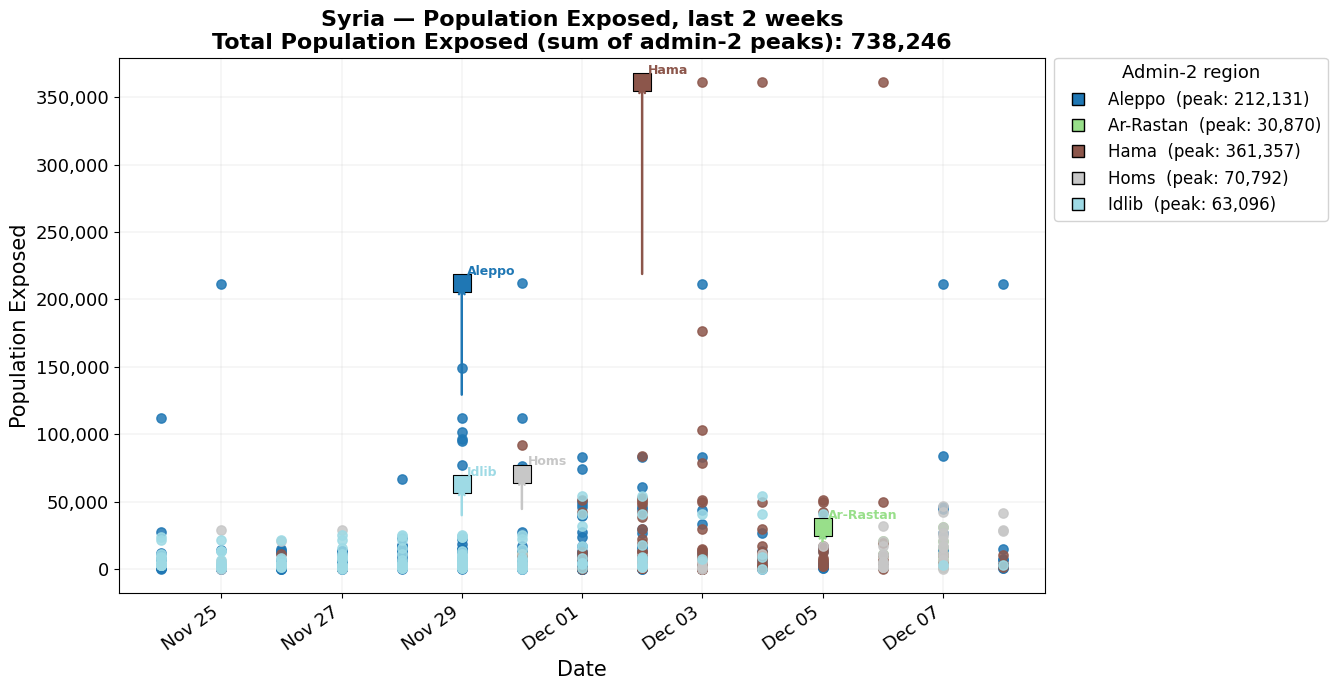

In [5]:
fig_ts, acled_pin = plot_acled_timeseries_2weeks(
    acled_out = acled_out,
    end_date  = date,
    title     = f"{country} — Population Exposed, last 2 weeks",
)

[MAP] Total unique events to plot: 2649
[MAP] Events with population_best: 2350
[MAP] Fatalities range: 0.0 – 105.0
[MAP] population_best range: 0.0 – 643072.0
[MAP] Admin-2 regions with pop_best_sum > 0: 24 / 60


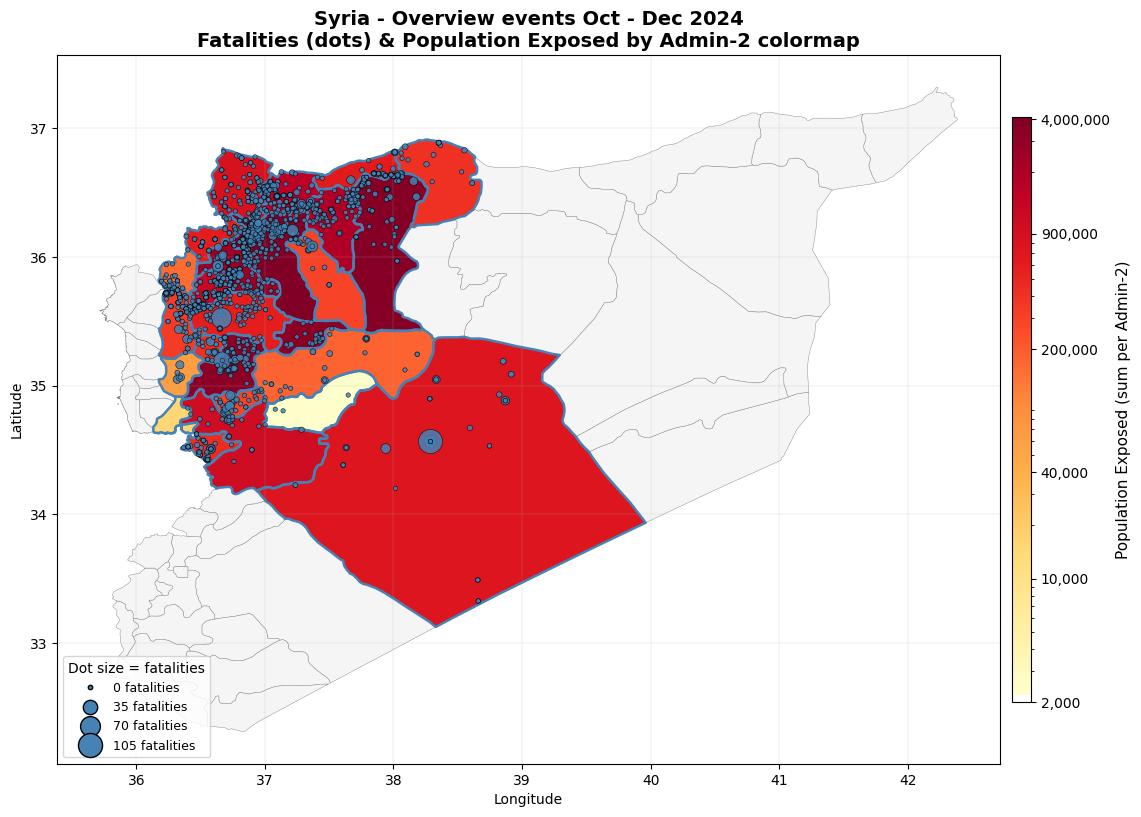

In [6]:
fig_map = plot_acled_events_map(
    acled_out    = acled_out,
    matched_poly = matched_polys,
    gpkg_path    = gpkg_path,
    iso3         = iso3,
    title        = title_overview,
)
fig_map.savefig("acled_map.png", dpi=150, bbox_inches="tight")

In [7]:
out, counts = fetch_idmc_displacements_by_admin(
    event_start_date=date,
    iso3=iso3,
    matched_polys=matched_polys,
    out_json_path=f"{country}_idmc_in_matched_admins.json",
    past_look_months=3,
)

print(out["meta"])
display(counts.head(10))

[DEBUG] len(matched_entries): 6
[DEBUG] first entry keys: ['id', 'country', 'iso3', 'latitude', 'longitude', 'centroid', 'role', 'displacement_type', 'qualifier', 'figure', 'displacement_date', 'displacement_start_date', 'displacement_end_date', 'year', 'event_id', 'event_name', 'event_codes', 'event_code_types', 'event_start_date', 'event_end_date', 'category', 'subcategory', 'type', 'subtype', 'standard_popup_text', 'standard_info_text', 'old_id', 'sources', 'source_url', 'locations_name', 'locations_coordinates', 'locations_accuracy', 'locations_type', 'displacement_occurred', 'created_at', '_matched_polygon_id']
[DEBUG] sample _matched_polygon_id values: [311271, 311268, 311280, 311251, 311280]
{'iso3': 'SYR', 'start_date': '2024-09-08', 'end_date': '2024-12-08', 'predicate': 'within', 'n_events_time_filtered': 6, 'n_events_with_coords': 6, 'n_events_inside_regions': 6, 'polygon_id_col': 'UID'}


,polygon_id,n_events
3,311280,3
0,311251,1
1,311268,1
2,311271,1


In [8]:
print(type(out))
print(out.keys())

# show first entry fully
first_key = list(out.keys())[0]
print("first key:", first_key)
print("first value:", out[first_key])

<class 'dict'>
dict_keys(['meta', 'events'])
first key: meta
first value: {'iso3': 'SYR', 'start_date': '2024-09-08', 'end_date': '2024-12-08', 'predicate': 'within', 'n_events_time_filtered': 6, 'n_events_with_coords': 6, 'n_events_inside_regions': 6, 'polygon_id_col': 'UID'}


[MAP] Total unique IDMC events to plot: 6
[MAP] Events with figure:               6
[MAP] Figure range: 11,023 – 1,100,000
[MAP] Admin-2 regions with figure_sum > 0: 4 / 60


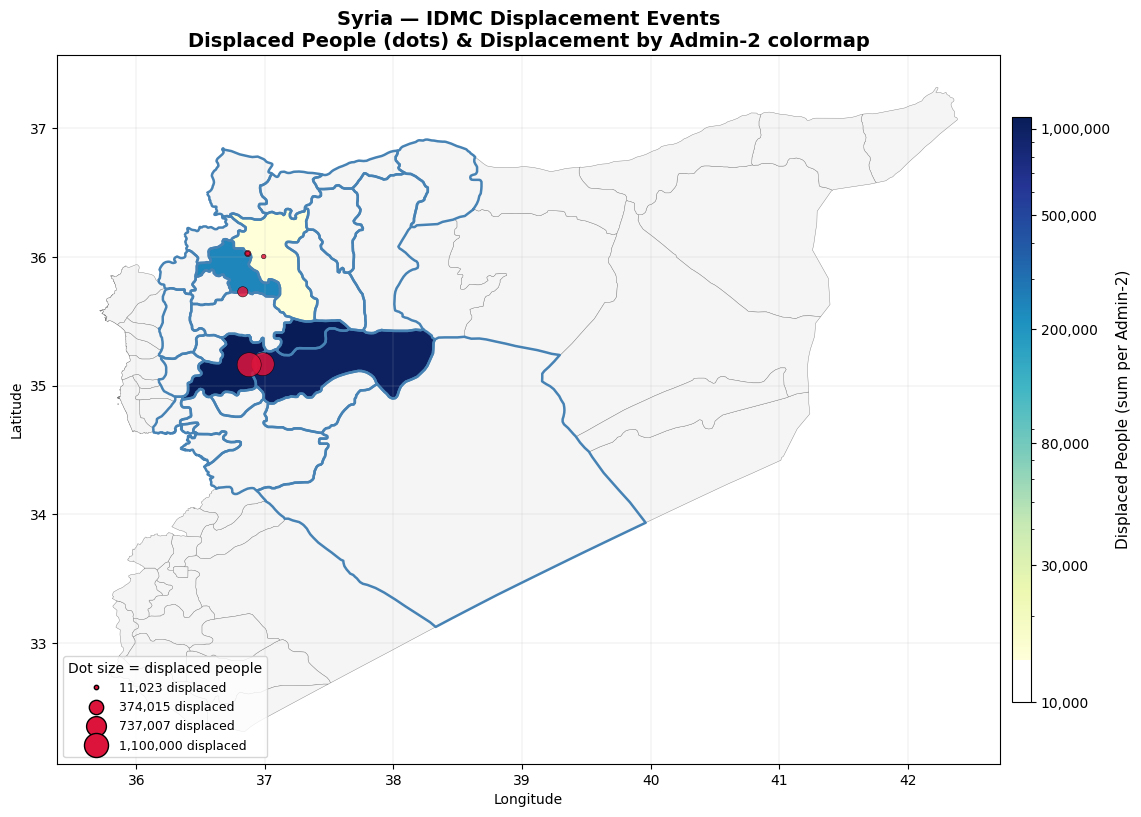

In [9]:
fig_idmc_map = plot_idmc_events_map(
    idmc_out     = out,
    matched_poly = matched_polys,
    gpkg_path    = gpkg_path,
    iso3         = iso3,
    title        = f"{country} — IDMC Displacement Events",
)

[TIMESERIES] Window: 2024-11-24 → 2024-12-08
[TIMESERIES] Admin regions with data: 4

[TIMESERIES] Total displaced people (sum of all figures): 1,240,500

[TIMESERIES] Peak figure per admin:
  Aleppo, Syria; Ar-Raqqah, Syria; Damascus, Damascus, Syria; Hama, Hama, Syria; Homs, Syria; Idlib, Syria; Latakia, Latakia, Syria; Tartus, Tartus, Syria:    1,000,000
  Aleppo, Mount Simeon District, Aleppo, Syria; Hama, Hama, Syria; Idlib, Syria:      178,000
  Aleppo, Mount Simeon District, Aleppo, Syria; Idlib, Syria:       48,500
  Aleppo, Syria; Idlib, Syria             :       14,000


/eos/jeodpp/home/users/mihadar/data/projects/PIN_project/PIN/idmc_fetch.py:961: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


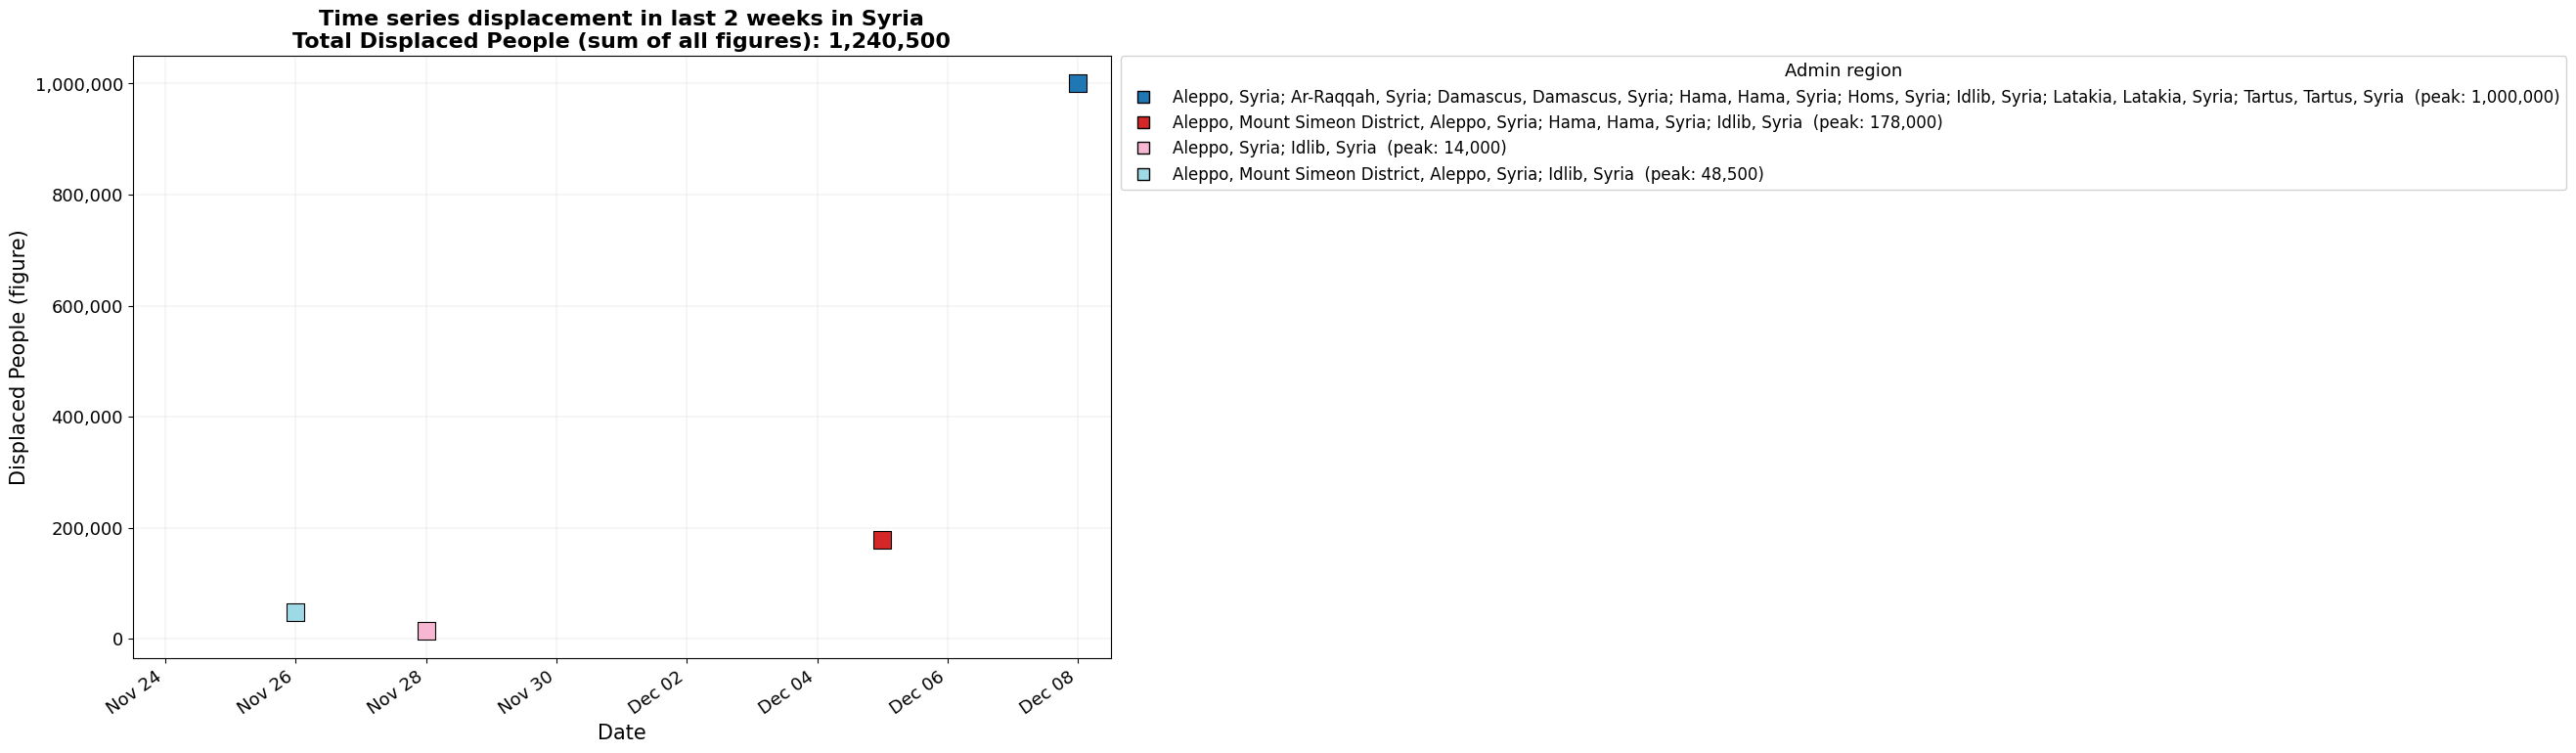

In [10]:
fig, total_figure = plot_idmc_timeseries_2weeks(
    idmc_out = out,
    end_date = date,
    title = f"Time series displacement in last 2 weeks in {country}")

In [11]:
print(total_figure)

1240500.0


# plot things

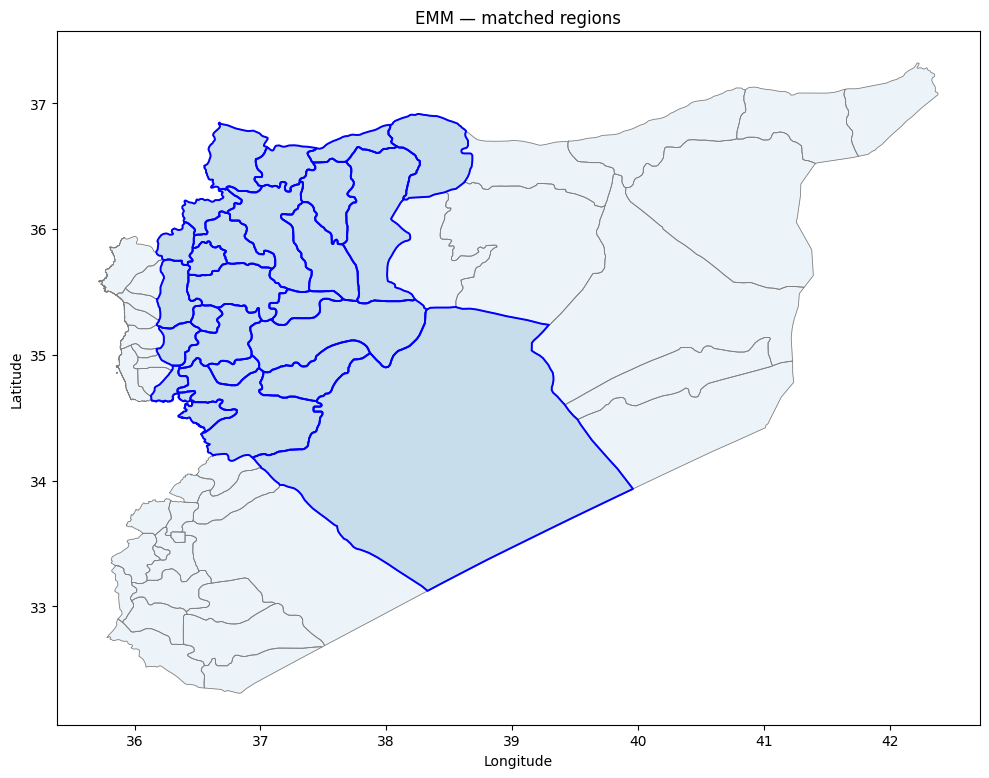

In [12]:
fig, ax = plot_gadm_matches_onefig(
    gpkg_path,
    matched_polys,
    country=country,
    points_df=summary_df,  # must have latitude/longitude
    title="EMM — matched regions",
)
plt.show()

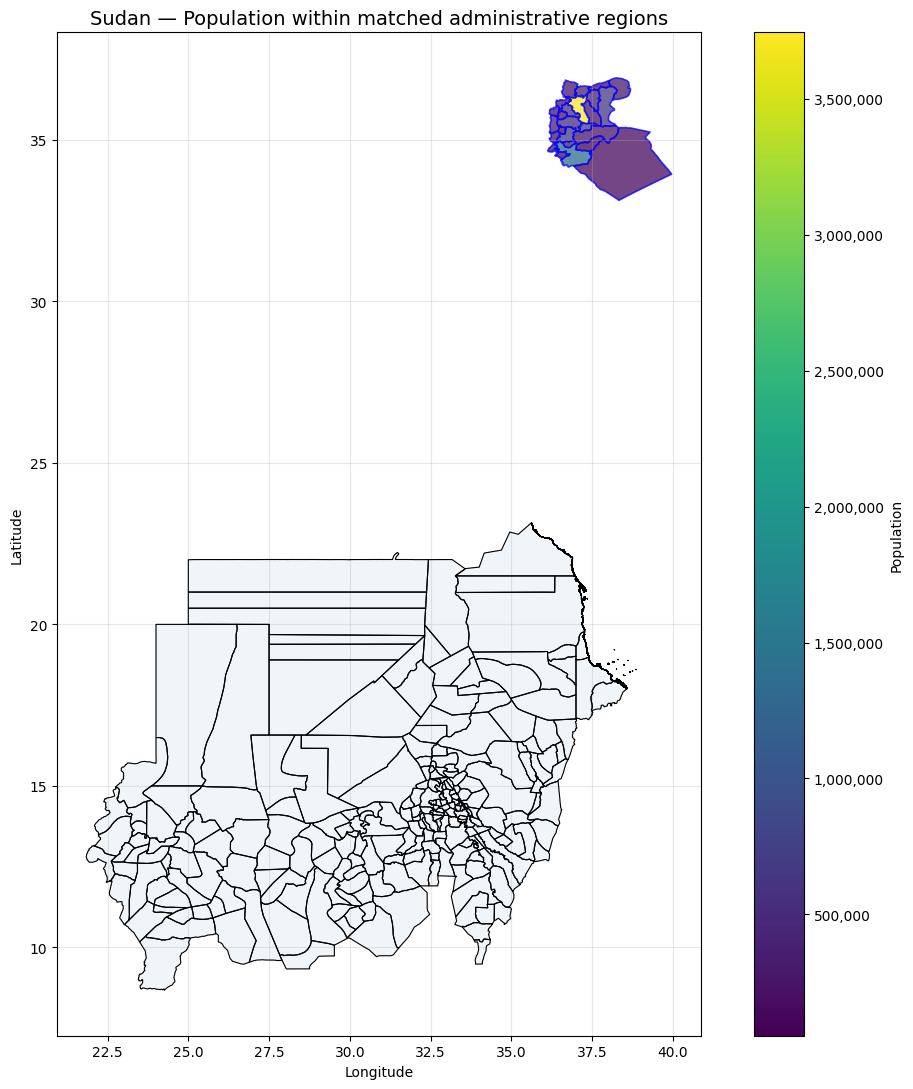

In [13]:
results_df, results_polys, fig, ax = extract_admin_pop(
    summary_df=summary_df,
    matched_poly=matched_polys,
    out_json_path=f"{country}_gadm_matches_with_population.json",
)


===== ADMIN POPULATION TABLE =====



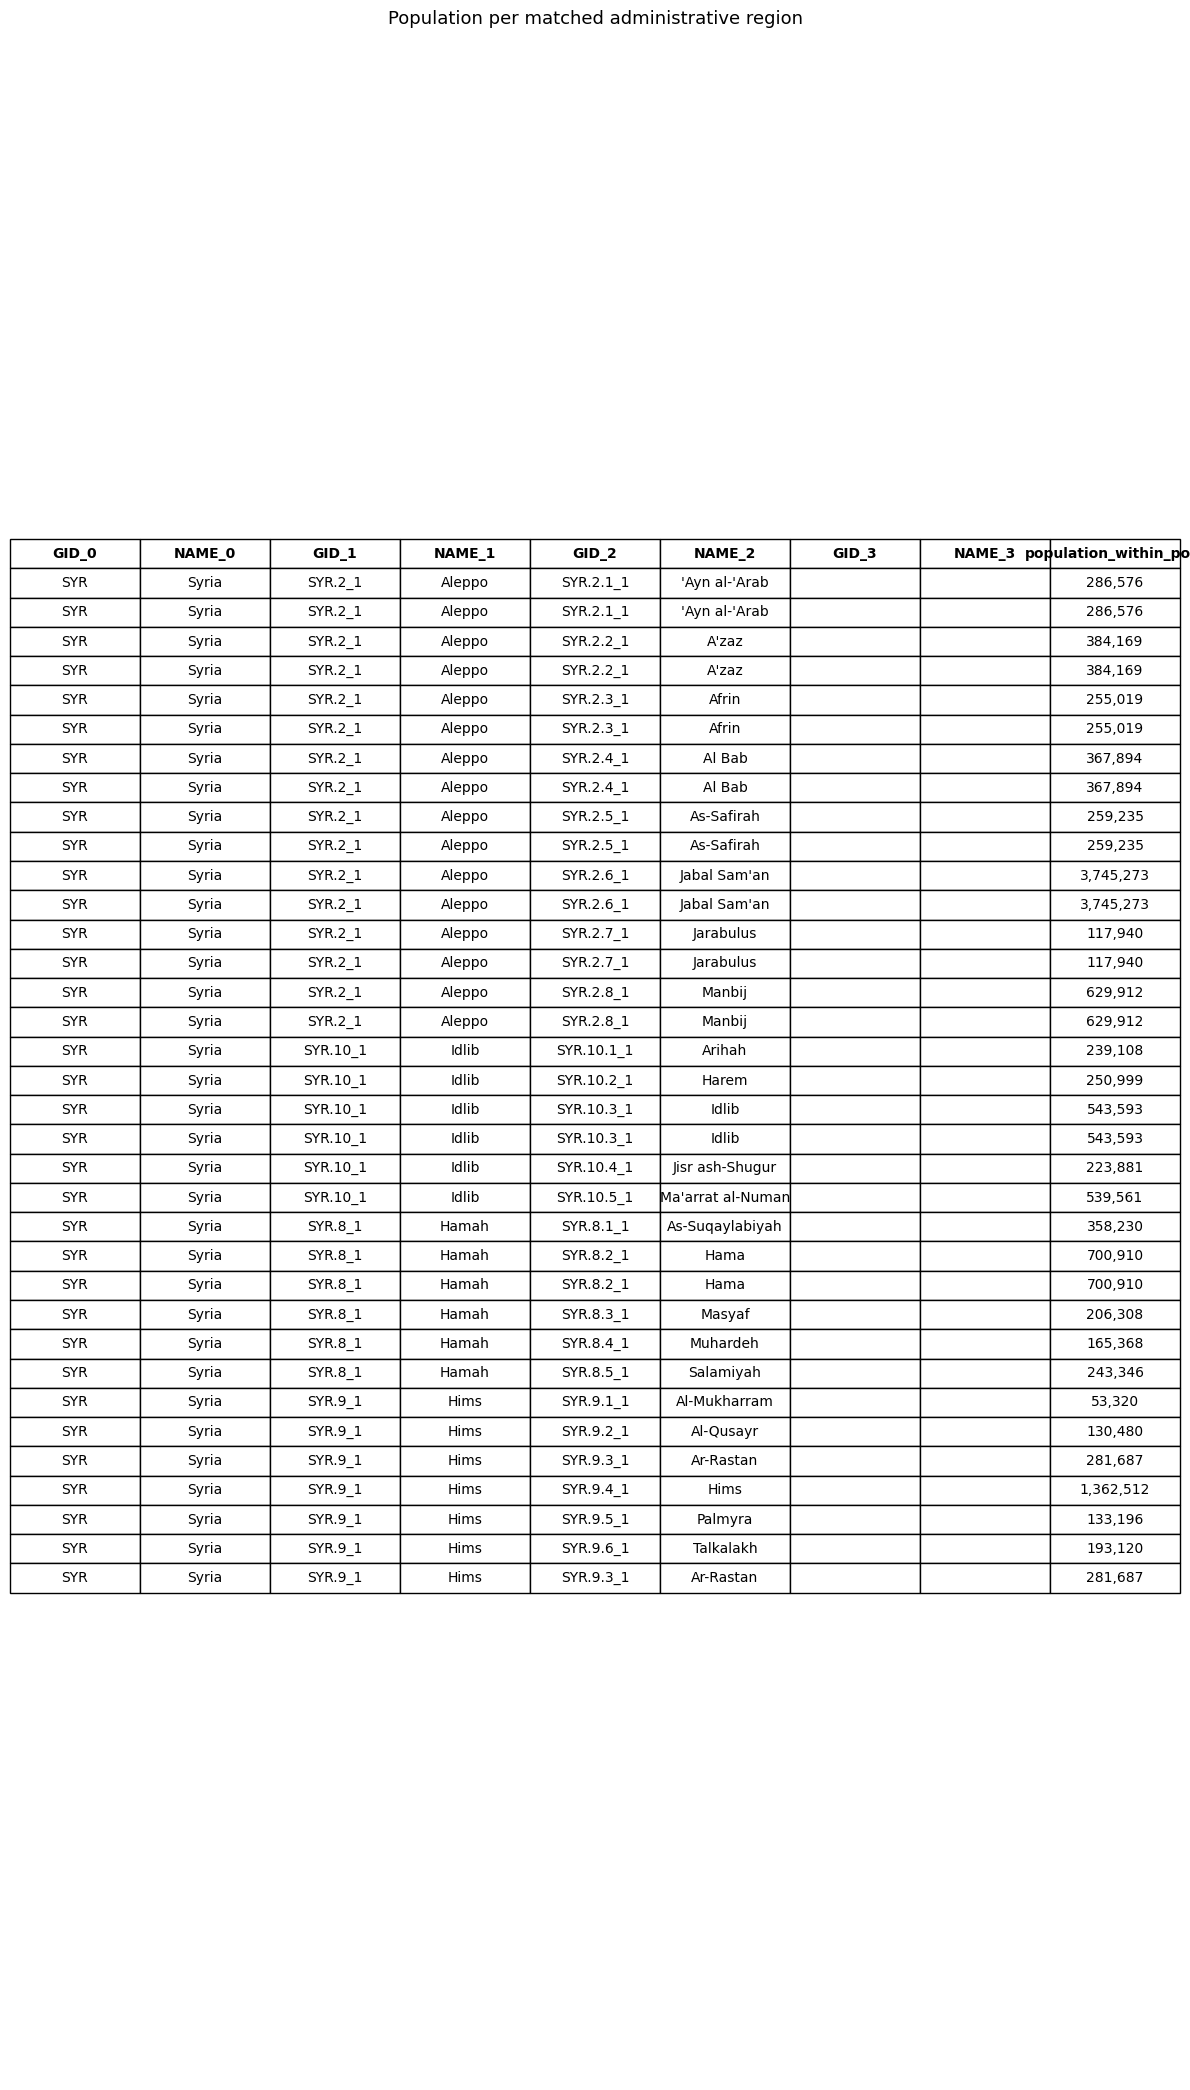

In [14]:
fig, ax, table_df = plot_admin_population_table(results_df)
plt.show()